# Lab: Modelling & Uncertainty — Forecasting China Companies CO2 Emissions (GIST Steel Dataset)
By Kerrian Le Bars

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error

Loading the plant-level steel production data provided by Global Energy Monitor.

In [66]:
# Set the file path
file_path = "Plant-level-data-Global-Iron-and-Steel-Tracker.xlsx"

# Load all necessary sheets
sheets = ["Plant data", "Plant capacities and status"]
dfs = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in sheets}

# Check that 'Plant ID' exists in each dataframe
for name, df in dfs.items():
    if 'Plant ID' not in df.columns:
        raise ValueError(f"'Plant ID' missing in sheet '{name}'")

# Function to select columns to merge
def select_merge_cols(base_df, new_df):
    cols = [col for col in new_df.columns if col not in base_df.columns or col == 'Plant ID']
    return new_df[cols]

# Merge the DataFrames with inner join to keep only the factories present in the 3 datasets
df_merged = dfs["Plant data"]
for sheet in sheets[1:]:
    df_merged = pd.merge(df_merged, 
                         select_merge_cols(df_merged, dfs[sheet]), 
                         on='Plant ID', 
                         how='inner')

Create the operational-plants dataset for 2020–2030 by checking each plant’s start and end dates. Plants with no end date are assumed to still be operational.

In [67]:
def get_operational_plants(df, year):
    """
    Filter plants that are considered operational in a given year.

    A plant is operational if:
    - Its start date is on or before the given year.
    - Its retirement date is on or after the given year, or is missing (NaT/unknown).
    - If multiple entries exist for the same Plant ID, keep the one with status = 'operating'
      (fallback: keep the first valid entry).
    """
    df_year = df.copy()
    
    # Parse date columns with an explicit YYYY-MM-DD format, coercing invalid dates to NaT
    df_year['Start date'] = pd.to_datetime(df_year['Start date'], format='%Y-%m-%d', errors='coerce')
    df_year['Retired date'] = pd.to_datetime(df_year['Retired date'], format='%Y-%m-%d', errors='coerce')
    
    # Select plants active in the given year:
    # - Start date <= December 31 of the target year
    # - Retired date >= January 1 of the target year, or missing
    operational = df_year[
        (df_year['Start date'] <= pd.Timestamp(year=year, month=12, day=31)) &
        ((df_year['Retired date'] >= pd.Timestamp(year=year, month=1, day=1)) |
         (df_year['Retired date'].isna()))
    ].copy()
    
    # If multiple entries exist for the same plant:
    # - Prefer entries explicitly marked as "operating"
    # - Otherwise keep the first occurrence
    if operational.duplicated('Plant ID').any():
        # Identify entries marked as operational/operating
        mask_operating = operational['Status'].str.lower() == 'operating'
        
        # Separate operating entries from others
        operating_entries = operational[mask_operating]
        fallback_entries = operational[~mask_operating]
        
        # Keep operating entries first; for plants without such entries,
        # keep a fallback entry
        operational = pd.concat([
            operating_entries,
            fallback_entries[~fallback_entries['Plant ID'].isin(operating_entries['Plant ID'])]
        ])
        
        # If duplicates remain, retain the first one
        operational = operational.drop_duplicates('Plant ID', keep='first')
        
    return operational

Case Study: China Steel Industry

In [83]:
# Filter for China only (more robust string match)
df_china = df_merged[df_merged['Country/Area'].str.strip().str.lower() == 'china'].copy()

# Define the range of analysis years
years = range(2020, 2031)

# Compute operational plants for China for each year
chinese_operational_plants = {
    year: get_operational_plants(df_china, year)
    for year in years
}

# Print formatted summary table
print("Operational Chinese Plants by Year")
print("-" * 40)
for year in years:
    count = len(chinese_operational_plants[year])
    print(f"{year}: {count:3d} plants")

Operational Chinese Plants by Year
----------------------------------------
2020: 150 plants
2021: 151 plants
2022: 147 plants
2023: 144 plants
2024: 144 plants
2025: 144 plants
2026: 144 plants
2027: 144 plants
2028: 144 plants
2029: 144 plants
2030: 144 plants


Compute China’s national steel utilization rate by dividing annual steel production (from the World Steel Association) by annual steelmaking capacity (from the OECD).

In [69]:
# Load global crude steel production data
file_path = "Country-crude-steel-production.xlsx"
world_crude_steel_production = pd.read_excel(
    file_path, 
    sheet_name="World crude steel production"
)

# Filter the dataset for China only (use standardized string matching)
china_steel_production = (
    world_crude_steel_production[
        world_crude_steel_production['Country'].str.strip().str.lower() == "china"
    ]
    .copy()
)

# Display China’s crude steel production data
display(china_steel_production)

,Country,2020,2021,2022,2023,2024
20,China,1064766.8,1035242.6,1017959.0,1028859.7,1005090.0


In [ ]:
# Create a DataFrame for China's steelmaking capacity by year (see OECD data)
# Images folder
years = range(2020, 2025)
capacities = [1_147_900, 1_146_500, 1_149_900, 1_141_500, 1_141_500]

china_steel_capacity = pd.DataFrame({
    "Year": list(years),
    "Capacity": capacities
})

# Display the DataFrame
display(china_steel_capacity)

,Year,Capacity
0,2020,1147900
1,2021,1146500
2,2022,1149900
3,2023,1141500
4,2024,1141500


In [71]:
# Copy to avoid modifying the original DataFrame
china_production_df = china_steel_production.copy()

# Identify year columns automatically (keep only numeric column names)
year_cols = [col for col in china_production_df.columns]

# Convert wide format (one column per year) into long format
china_production_long = (
    china_production_df
    .melt(id_vars='Country', value_vars=year_cols,
          var_name='Year', value_name='Production')
)

# Convert year to an integer and drop rows where conversion failed
china_production_long['Year'] = pd.to_numeric(china_production_long['Year'], errors='coerce')
china_production_long = china_production_long.dropna(subset=['Year'])
china_production_long['Year'] = china_production_long['Year'].astype(int)

In [72]:
# Merge production with capacity
china_merged = china_production_long.merge(
    china_steel_capacity,
    on='Year',
    how='inner'
)

# Compute utilization rate 
china_merged['Utilization_Rate'] = (
    china_merged['Production'] / china_merged['Capacity']
)

# Display results
display(china_merged[['Year', 'Production', 'Capacity', 'Utilization_Rate']])

,Year,Production,Capacity,Utilization_Rate
0,2020,1064766.8,1147900,0.927578
1,2021,1035242.6,1146500,0.902959
2,2022,1017959.0,1149900,0.885259
3,2023,1028859.7,1141500,0.901323
4,2024,1005090.0,1141500,0.880499


Apply this utilization rate to each plant in order to estimate plant-level steel production.

In [73]:
# Enable explicit warnings for downcasting
pd.set_option('future.no_silent_downcasting', True)

# Create dictionary of national production ratios by year
production_ratios = (
    china_merged
    .set_index("Year")["Utilization_Rate"]
    .to_dict()
)

# Function to compute plant-level steel production
def calculate_plant_production(df_plants, year):
    """
    Compute estimated plant-level steel production for a given year.
    
    Production is allocated proportionally to each plant's capacity 
    (BOF and EAF), using the national utilization ratio for the year.
    """
    
    # 1. Check that we have a national ratio for that year
    if year not in production_ratios:
        raise ValueError(f"No production ratio available for year {year}")
    
    ratio = production_ratios[year]
    df = df_plants.copy()
    
    # 2. Validate required columns
    required_cols = [
        'Plant ID',
        'Nominal BOF steel capacity (ttpa)', # China’s crude steel production is exclusively via two routes:
        'Nominal EAF steel capacity (ttpa)'  # Basic Oxygen Furnace (BOF) and Electric Arc Furnace (EAF)
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")
    
    # 3. Convert capacity columns to numeric (missing → 0)
    capacity_cols = [
        'Nominal BOF steel capacity (ttpa)',
        'Nominal EAF steel capacity (ttpa)'
    ]
    df[capacity_cols] = df[capacity_cols].apply(
        lambda col: pd.to_numeric(col, errors='coerce').fillna(0)
    )
    
    # 4. Compute production
    df['Production_BF_BOF'] = df['Nominal BOF steel capacity (ttpa)'] * ratio
    df['Production_EAF'] = df['Nominal EAF steel capacity (ttpa)'] * ratio
    df['Total_Production'] = df['Production_BF_BOF'] + df['Production_EAF']
    df['Year'] = year
    
    return df

In [74]:
# Compute plant-level production for each year
# Utilization rate data is available only for 2020–2024
years_to_compute = range(2020, 2025)
production_dfs = []

for year in years_to_compute:
    df_plants = chinese_operational_plants.get(year)
    if df_plants is None:
        print(f"No operational plant dataset for {year}")
        continue
    
    try:
        df_year = calculate_plant_production(df_plants, year)
        production_dfs.append(df_year)
    except Exception as e:
        print(f" Failed to compute production for {year}: {e}")

In [75]:
# Concatenate all results and build the final dataset
if production_dfs:
    all_production = pd.concat(production_dfs, ignore_index=True)

    result_cols = [
        'Plant ID', 'Year', 'Owner', 'Status',
        'Nominal BOF steel capacity (ttpa)',
        'Nominal EAF steel capacity (ttpa)',
        'Production_BF_BOF', 'Production_EAF', 'Total_Production'
    ]

    china_plant_production = all_production[result_cols].copy()
    display(china_plant_production.head().round(2))

else:
    print("No production data could be computed.")

,Plant ID,Year,Owner,Status,Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Production_BF_BOF,Production_EAF,Total_Production
0,P100000120219,2020,Angang Steel Co Ltd,operating,20650.0,0.0,19154.49,0.00,19154.49
1,P100000120071,2020,Anhui Guihang Special Steel Co Ltd,operating,2700.0,0.0,2504.46,0.00,2504.46
2,P100001025923,2020,"Guangde Xinyuanda Metal Products Co., Ltd. Co Ltd",operating,0.0,500.0,0.00,463.79,463.79
3,P100000120231,2020,Anshan Baode Iron & Steel Co Ltd,operating,1800.0,0.0,1669.64,0.00,1669.64
4,P100000120221,2020,Angang Steel Co Ltd,operating,2100.0,0.0,1947.91,0.00,1947.91


In [76]:
# Identify plants with zero total production over the entire period
zero_production_plants = (
    china_plant_production
    .groupby('Plant ID')['Total_Production']
    .sum()
    .reset_index()
)

zero_production_plants = zero_production_plants[
    zero_production_plants['Total_Production'] == 0
]

# Process plants with zero production
if not zero_production_plants.empty:
    # Retrieve full details of these plants
    zero_production_details = china_plant_production[
        china_plant_production['Plant ID'].isin(zero_production_plants['Plant ID'])
    ].drop_duplicates('Plant ID')
    
    # Keep only plants with status 'operating'
    operating_zero_production = zero_production_details[
        zero_production_details['Status'].str.lower() == 'operating'
    ]
    
    if not operating_zero_production.empty:
        print(f"Number of 'operating' plants with zero production (2020-2024): {len(operating_zero_production)}\n")
        
        # Display relevant plant details
        display(
            operating_zero_production[[
                'Plant ID', 'Owner', 'Status',
                'Nominal BOF steel capacity (ttpa)',
                'Nominal EAF steel capacity (ttpa)'
            ]]
        )
        
        # Remove these plants from the main DataFrame
        plants_to_remove = operating_zero_production['Plant ID'].unique()
        initial_count = len(china_plant_production)
        china_plant_production = china_plant_production[
            ~china_plant_production['Plant ID'].isin(plants_to_remove)
        ]
        
        print(f"\n{len(plants_to_remove)} 'operating' plants with zero production have been removed.")
        print(f"Total entries before removal: {initial_count}")
        print(f"Total entries after removal: {len(china_plant_production)}")
    
    else:
        print("No 'operating' plants with zero production over 2020-2024 were found.")
else:
    print("No plants with zero production over 2020-2024 were found.")

Number of 'operating' plants with zero production (2020-2024): 8



,Plant ID,Owner,Status,Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa)
15,P100000120351,Fushun HANWANG Direct Reduced Iron Co Ltd,operating,0.0,0.0
31,P100000120217,JiLin Province Xinda Steel Co Ltd,operating,0.0,0.0
59,P100000120236,Shaanxi Lueyang Iron and Steel Co Ltd,operating,0.0,0.0
65,P100000120406,Shanxi HUAQIANG Iron and Steel Co Ltd,operating,0.0,0.0
73,P100000120271,Shanxi Zhongsheng Iron and Steel Co Ltd,operating,0.0,0.0
86,P100000120297,Honghe Iron and Steel Co Ltd,operating,0.0,0.0
87,P100000120299,WISCO Group Kunming Steel Co Ltd,operating,0.0,0.0
94,P100000120292,Xinjiang Kunyu Lron & Steel Co Ltd,operating,0.0,0.0



8 'operating' plants with zero production have been removed.
Total entries before removal: 736
Total entries after removal: 696


Retrieve emission factors for Chinese steel plants, classified by production technology (BF-BOF & EAF), referencing the Hasanbeigi report. Assign an emission factor to each plant based on its technology, and calculate plant-level emissions by multiplying the factor with production.

In [ ]:
# Define emission intensities (see Global Efficiency Intelligence & Berkeley Lab)
# Images folder
EMISSION_INTENSITY_BF_BOF = 2.1  # in tCO2/tonne
EMISSION_INTENSITY_EAF = 1.3     # in tCO2/tonne

# Compute emissions by production type
china_plant_emissions_df = china_plant_production.copy()
china_plant_emissions_df['Emissions_BF_BOF'] = china_plant_emissions_df['Production_BF_BOF'] * EMISSION_INTENSITY_BF_BOF
china_plant_emissions_df['Emissions_EAF'] = china_plant_emissions_df['Production_EAF'] * EMISSION_INTENSITY_EAF

# Total emissions per plant and year
china_plant_emissions_df['Total_Emissions'] = china_plant_emissions_df['Emissions_BF_BOF'] + china_plant_emissions_df['Emissions_EAF']

# Display the result
display(china_plant_emissions_df.head())

,Plant ID,Year,Owner,Status,Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Production_BF_BOF,Production_EAF,Total_Production,Emissions_BF_BOF,Emissions_EAF,Total_Emissions
0,P100000120219,2020,Angang Steel Co Ltd,operating,20650.0,0.0,19154.485948,0.000000,19154.485948,40224.420491,0.000000,40224.420491
1,P100000120071,2020,Anhui Guihang Special Steel Co Ltd,operating,2700.0,0.0,2504.460632,0.000000,2504.460632,5259.367328,0.000000,5259.367328
2,P100001025923,2020,"Guangde Xinyuanda Metal Products Co., Ltd. Co Ltd",operating,0.0,500.0,0.000000,463.789006,463.789006,0.000000,602.925708,602.925708
3,P100000120231,2020,Anshan Baode Iron & Steel Co Ltd,operating,1800.0,0.0,1669.640422,0.000000,1669.640422,3506.244885,0.000000,3506.244885
4,P100000120221,2020,Angang Steel Co Ltd,operating,2100.0,0.0,1947.913825,0.000000,1947.913825,4090.619033,0.000000,4090.619033


Aggregate emissions from individual plants to derive total CO₂ emissions at the corporate level.

In [78]:
# Check that the required columns exist before aggregation
required_cols = [
    'Owner', 'Production_BF_BOF', 'Production_EAF',
    'Emissions_BF_BOF', 'Emissions_EAF',
    'Total_Production', 'Total_Emissions', 'Plant ID', 'Year'
]

if all(col in china_plant_emissions_df.columns for col in required_cols):
    # Aggregate data by owner and year
    owner_summary = (
        china_plant_emissions_df
        .groupby(['Owner', 'Year'], as_index=False)
        .agg({
            'Production_BF_BOF': 'sum',
            'Production_EAF': 'sum',
            'Emissions_BF_BOF': 'sum',
            'Emissions_EAF': 'sum',
            'Total_Production': 'sum',
            'Total_Emissions': 'sum',
            'Plant ID': 'count'
        })
    )

    # Rename columns for clarity
    owner_summary = owner_summary.rename(columns={
        'Plant ID': 'Number_of_Plants',
        'Total_Production': 'Total_Steel_Production',
        'Total_Emissions': 'Total_CO2_Emissions'
    })

    # Compute production shares by technology
    owner_summary['BF_BOF_Share'] = (
        owner_summary['Production_BF_BOF'] / owner_summary['Total_Steel_Production'] * 100
    ).round(1)
    
    owner_summary['EAF_Share'] = (
        owner_summary['Production_EAF'] / owner_summary['Total_Steel_Production'] * 100
    ).round(1)

    # Sort by year and total steel production (descending within year)
    owner_summary = owner_summary.sort_values(
        by=['Year', 'Total_Steel_Production'],
        ascending=[True, False]
    )
    
    # Display the dataframe
    display(owner_summary.head())

,Owner,Year,Production_BF_BOF,Production_EAF,Emissions_BF_BOF,Emissions_EAF,Total_Steel_Production,Total_CO2_Emissions,Number_of_Plants,BF_BOF_Share,EAF_Share
0,Angang Steel Co Ltd,2020,21102.399773,0.000000,44315.039524,0.000000,21102.399773,44315.039524,2,100.0,0.0
656,Zhangjiagang Hongchang Steel Co Ltd,2020,12867.362183,2852.302387,27021.460584,3707.993103,15719.664570,30729.453687,1,81.9,18.1
520,Wuhan Iron and Steel Co Ltd,2020,14754.983437,0.000000,30985.465218,0.000000,14754.983437,30985.465218,1,100.0,0.0
125,Inner Mongolia BaoTou Steel Union Co Ltd,2020,14479.492768,0.000000,30406.934812,0.000000,14479.492768,30406.934812,1,100.0,0.0
433,Shanxi Taigang Stainless Steel Co Ltd,2020,8162.686506,3394.935524,17141.641662,4413.416181,11557.622030,21555.057843,1,70.6,29.4


In [79]:
# Identify owners with at least one year of zero production
zero_prod_mask = (
    (owner_summary['Total_Steel_Production'] == 0) |
    ((owner_summary['Production_BF_BOF'] + owner_summary['Production_EAF']) == 0)
)

owners_with_zero_prod = owner_summary.loc[zero_prod_mask, 'Owner'].unique()

# Count affected owners and compute percentage
count_owners_with_zero = len(owners_with_zero_prod)
total_unique_owners = owner_summary['Owner'].nunique()
percent_zero_owners = round((count_owners_with_zero / total_unique_owners * 100), 1)

print(f"Number of owners with at least one year of zero production (2020-2024): {count_owners_with_zero}")
print(f"Total unique owners: {total_unique_owners}")
print(f"Share of owners affected: {percent_zero_owners}%")

# Display a sample of affected owners (up to 10)
if count_owners_with_zero > 0:
    print("\nSample of affected owners:")
    display(
        owner_summary[
            owner_summary['Owner'].isin(owners_with_zero_prod[:10])
        ][['Owner', 'Year', 'Total_Steel_Production']]
        .sort_values(['Owner', 'Year'])
    )

Number of owners with at least one year of zero production (2020-2024): 1
Total unique owners: 147
Share of owners affected: 0.7%

Sample of affected owners:


,Owner,Year,Total_Steel_Production
299,Mintal Group Co Ltd,2021,0.0
300,Mintal Group Co Ltd,2022,0.0
301,Mintal Group Co Ltd,2023,0.0
302,Mintal Group Co Ltd,2024,0.0


In [80]:
# Remove a specific owner from the dataset
owner_to_remove = "Mintal Group Co Ltd"
owner_summary_cleaned = owner_summary[owner_summary['Owner'] != owner_to_remove].copy()

# Save the cleaned dataset to CSV
output_file = 'owner_emissions_cleaned.csv'
owner_summary_cleaned.to_csv(output_file, index=False)

print(f"Removed owner '{owner_to_remove}' and saved cleaned dataset to '{output_file}'")

Removed owner 'Mintal Group Co Ltd' and saved cleaned dataset to 'owner_emissions_cleaned.csv'


Estimate future emissions at the company level based on current data and trends.

In [81]:
# Load the CSV dataset
file_path = "owner_emissions_cleaned.csv"
df = pd.read_csv(file_path)

# Clean the data
# Remove rows with missing values in critical columns
df = df.dropna(subset=["Owner", "Year", "Total_CO2_Emissions"])

# Ensure columns have the correct data types
df["Year"] = df["Year"].astype(int)
df["Total_CO2_Emissions"] = df["Total_CO2_Emissions"].astype(float)

# Select a company for analysis
company_list = sorted(df["Owner"].unique())  # Sorted list of all companies
selected_company = company_list[0]           # Select the first company (can change)

# Filter data for the selected company and sort by year
company_data = df[df["Owner"] == selected_company].sort_values("Year")
X = company_data["Year"].values.reshape(-1, 1)  # Years as a 2D array for sklearn
y = company_data["Total_CO2_Emissions"].values  # Corresponding CO2 emissions

# Prepare future years for prediction
last_year = company_data["Year"].max()
future_years = np.arange(last_year + 1, 2031)  # Generate future years up to 2030
all_years = np.concatenate([X.flatten(), future_years])  # Combine past and future years

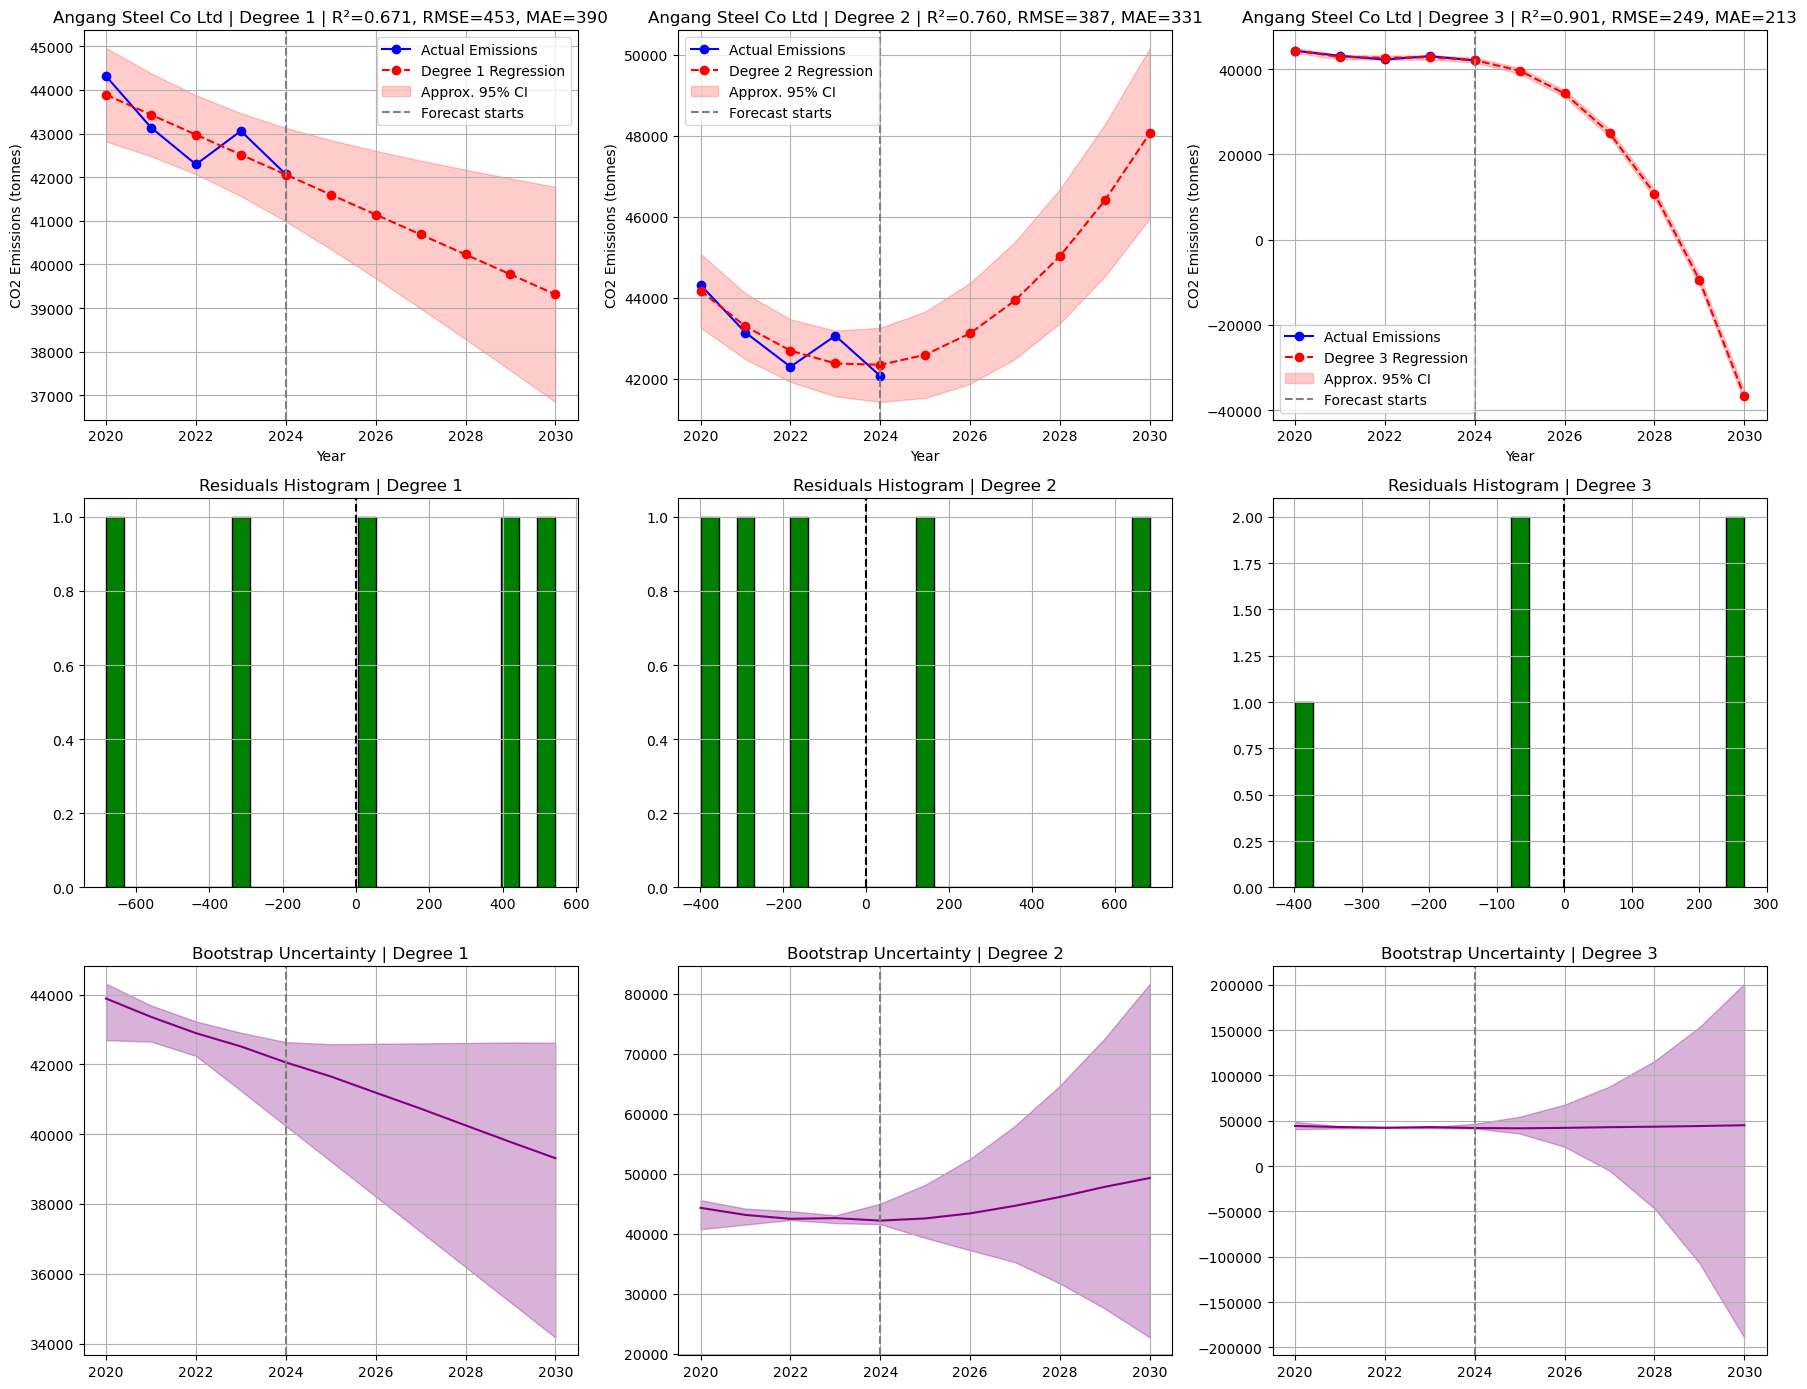

In [85]:
# Load CSV
file_path = "owner_emissions_cleaned.csv"
df = pd.read_csv(file_path)

# Clean data
df = df.dropna(subset=["Owner", "Year", "Total_CO2_Emissions"])
df["Year"] = df["Year"].astype(int)
df["Total_CO2_Emissions"] = df["Total_CO2_Emissions"].astype(float)

# Select company
company_list = sorted(df["Owner"].unique())
selected_company = company_list[0]

company_data = df[df["Owner"] == selected_company].sort_values("Year")
X = company_data["Year"].values.reshape(-1, 1)
y = company_data["Total_CO2_Emissions"].values

# Future years for prediction
last_year = company_data["Year"].max()
future_years = np.arange(last_year + 1, 2031)
all_years = np.concatenate([X.flatten(), future_years])

# Settings
degrees = [1, 2, 3]
n_bootstrap = 300          # number of bootstrap draws

plt.figure(figsize=(18, 14))

for i, degree in enumerate(degrees, 1):

    # Polynomial model
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    # Full prediction
    all_X_poly = poly.transform(all_years.reshape(-1, 1))
    all_pred = model.predict(all_X_poly)

    # Residual uncertainty (original)
    residuals = y - model.predict(X_poly)
    s = np.std(residuals)
    distance_factor = np.sqrt(1 + ((all_years - np.mean(X))**2) /
                              np.sum((X.flatten() - np.mean(X))**2))
    upper = all_pred + 2 * s * distance_factor
    lower = all_pred - 2 * s * distance_factor

    # Metrics
    rmse = np.sqrt(np.mean(residuals**2))
    mae = mean_absolute_error(y, model.predict(X_poly))
    r2 = model.score(X_poly, y)

    # Subplot : regression + CI
    plt.subplot(3, 3, i)
    plt.plot(company_data["Year"], y, 'o-', label="Actual Emissions", color='blue')
    plt.plot(all_years, all_pred, 'o--', label=f"Degree {degree} Regression", color='red')
    plt.fill_between(all_years, lower, upper, color='red', alpha=0.2, label="Approx. 95% CI")
    plt.axvline(x=last_year, color='gray', linestyle='--', label="Forecast starts")
    plt.xlabel("Year")
    plt.ylabel("CO2 Emissions (tonnes)")
    plt.grid(True)
    plt.title(f"{selected_company} | Degree {degree} | R²={r2:.3f}, RMSE={rmse:.0f}, MAE={mae:.0f}")
    plt.legend()

    # Subplot : histogram of residuals
    plt.subplot(3, 3, i + 3)
    plt.hist(residuals, bins=25, color='green', edgecolor='black')
    plt.axvline(0, linestyle='--', color='black')
    plt.title(f"Residuals Histogram | Degree {degree}")
    plt.grid(True)

    # Subplot : bootstrap uncertainty (NEW)
    bootstrap_preds = np.zeros((n_bootstrap, len(all_years)))

    for b in range(n_bootstrap):
        X_bs, y_bs = resample(X, y)
        X_bs_poly = poly.fit_transform(X_bs)
        model_bs = LinearRegression()
        model_bs.fit(X_bs_poly, y_bs)
        bootstrap_preds[b, :] = model_bs.predict(all_X_poly)

    # Compute intervals
    lower_bs = np.percentile(bootstrap_preds, 5, axis=0)
    upper_bs = np.percentile(bootstrap_preds, 95, axis=0)
    median_bs = np.percentile(bootstrap_preds, 50, axis=0)

    plt.subplot(3, 3, i + 6)
    plt.plot(all_years, median_bs, label="Bootstrap median", color='purple')
    plt.fill_between(all_years, lower_bs, upper_bs, alpha=0.3, color='purple')
    plt.axvline(last_year, linestyle='--', color='gray')
    plt.title(f"Bootstrap Uncertainty | Degree {degree}")
    plt.grid(True)

plt.tight_layout()
plt.show()

### General Note on Emissions Modelling

To estimate future CO₂ emissions from Chinese steel plants, we chose to use a linear regression model.

The model is trained on emissions data from 2020 to 2024 to capture the overall trend in emissions evolution. This choice of a simple regression is justified by the conclusions of Lab2: only historical production data had a real impact on predicting the following year's production, while other static variables had a limited influence.

To obtain a more accurate model, it would have been necessary to have additional dynamic data, such as changes in workforce, plant capacity, or the distribution of production by technology.

However, the dataset used remains very limited. The historical emissions data only covers four years, which is relatively short. Furthermore, the method for calculating production—and therefore emissions—is aggregated at the global level, implying that all factories follow the same evolutionary dynamics, even though their emission values ​​differ. In reality, production exhibits far more variability than a simple calculation based on the average utilization rate of Chinese industry. These limitations make the modeling highly linear, thus justifying the initial choice of linear regression.

The results of emission modeling should be interpreted with caution. To account for this uncertainty, we have chosen to accompany each model with a confidence interval, calculated from the model residuals. This allows us to assess not only the predicted central tendency, but also the possible variability around this estimate.

To better capture variability and explore different scenarios, we also tested polynomial regressions of degree 1 to 3.

1. For the first-degree model (linear regression):

- The coefficient of determination R² is 0.671, indicating that the model explains approximately 67% of the variance observed in the data. While this is reasonable, a significant portion of the variability remains unexplained.
- The root mean square error (RMSE) is 453, while the mean absolute error (MAE) is 390. These values ​​reflect the average difference between the model predictions and the emissions actually observed.
- The model captures a general downward trend in CO₂ emissions for Chinese factories, with a prediction of around 41600 for 2025, then 41100 for 2026, and so on for subsequent years.

Overall, the model appears consistent and accurately reflects the general trend, although the proportion of variability explained by past emissions remains limited to 67%. The confidence interval associated with these predictions is relatively wide, reflecting the model's significant uncertainty. This suggests several plausible scenarios: emissions reductions could occur more slowly or more rapidly than predicted by the central trend.

Thus, although the model provides a useful estimate of emission dynamics, it is important to consider it as an exploratory tool rather than an exact forecast, especially due to unexplained variability and the limited duration of the historical data.

2. For the second-degree model (quadratic regression):

- The coefficient of determination R² is 0.760, indicating that the model explains approximately 76% of the variance observed in the data. This value is higher than that of the linear model, suggesting a better ability to capture the trend in emissions.
- The root mean square error (RMSE) is 387 and the mean absolute error (MAE) is 331, lower values ​​than those of the linear model, reflecting a more accurate fit to historical data.
- The model predicts a slightly increasing trend in CO₂ emissions for Chinese factories, with values ​​of around 42300 for 2025, then 44300 for 2026, and so on for subsequent years.

Although this quadratic model appears theoretically superior to linear regression, it has some significant limitations. Polynomial models tend to overfit historical data, which can lead to unrealistic predictions when extrapolating over several years. In particular, the rapid increase in emissions suggested by the model seems unlikely, given technological advancements and emissions reduction efforts in the steel industry (not reflected in our data).

Nevertheless, this model offers an interesting alternative scenario, illustrating a possible increase in CO₂ emissions if certain internal industry trends or dynamics were to materialize. As with the linear model, the confidence interval remains wide, reflecting significant uncertainty in future forecasts. This scenario should therefore be interpreted with caution and considered an exploration rather than a precise estimate.

3. For the degree 3 model (cubic regression):

- The coefficient of determination R² is 0.901, indicating that the model explains approximately 90% of the variance observed in the data. This high value reflects a very accurate fit to the historical data.
- The root mean square error (RMSE) is 249 and the mean absolute error (MAE) is 213, values ​​significantly lower than those of the linear and quadratic models, confirming better statistical performance on the available data.
- The model predicts a very marked decrease in CO₂ emissions for Chinese factories, with values ​​of around 39500 for 2025, then 31000 for 2026, and continuing a sharp decrease in subsequent years.

Although this cubic model appears theoretically superior to the linear and quadratic models, it is clearly a case of overfitting. The sharp decrease in emissions and the prediction of potentially negative values ​​by 2029 demonstrate that the model does not reflect industrial reality. Consequently, predictions for future years are very likely inaccurate and should not be used as reliable estimates.

This model nevertheless illustrates the importance of considering model complexity in relation to the quantity and quality of available data. The higher the degree of the polynomial, the better the model can fit past fluctuations, but at the risk of generating unrealistic extrapolations. The associated confidence interval also remains very wide, reinforcing the need for caution in interpreting the results.

In conclusion, the linear regression model (degree 1 modeling) appears to be the most reliable estimate for predicting CO₂ emissions.

### Note on Uncertainty Quantification in Modeling and Linear Regression

Uncertainty quantification (UQ) involves evaluating and characterizing the uncertainty associated with a model's predictions. In the context of statistical modeling, and more specifically linear regression, it is essential to distinguish the different sources of uncertainty and to integrate methods for rigorously quantifying them.

1. Main sources of uncertainty

- Data uncertainty (random/noise): Observations always contain a random component. In linear regression, this uncertainty is represented by the error term ε
- Parametric uncertainty: Even if the model structure is correct, the coefficients $β$ are estimated from a limited sample of data. This estimate is therefore subject to fluctuations that depend on the size and quality of the data.
- Modeling uncertainty (structural/systematic): Linear regression relies on the assumption of a linear relationship between the explanatory variables and the target variable. If this assumption is incorrect (non-linearity, unmodeled interactions), the predictions may be biased.

- Prediction uncertainty (extrapolation): Uncertainty increases when the model is used to predict values ​​outside the range of observed data, because the behavior of the system is no longer guaranteed by the observations.

2. Methods for evaluating uncertainty in linear regression

- Confidence interval for the coefficients: Each coefficient $β_{i}$ can be associated with a confidence interval, allowing the variability of the estimate to be quantified.
- Prediction interval for new observations: To predict a new value $y_{new}$ from $X_{new}$, we can construct a prediction interval that takes into account both the residual error and the uncertainty in the coefficients. This interval is wider than the confidence interval of the coefficients and reflects the overall uncertainty of the prediction.

- Residue analysis: Examining the residuals makes it possible to detect poorly fitted models, non-linearities or heteroscedasticities, which are sources of uncertainty not captured by the model.
- Bootstrap: By resampling the data with replacement, we can estimate the sampling distribution of the coefficients and construct confidence intervals or prediction intervals.
- Monte Carlo simulation: By simulating the distribution of the coefficients, we can construct confidence intervals or prediction intervals.

3. The importance of quantifying uncertainty

- Provides safety margins for decision-making (e.g., industrial planning, climate policy).
- Allows you to compare different models not only on their fit, but also on their robustness.
- Helps identify plausible scenarios when data is limited or noisy.

Linear regression is simple and interpretable, but its ability to represent uncertainty relies on assumptions: normality of errors, homoscedasticity, and independence of observations. In situations where these assumptions are partially violated or where the data are very limited (as in our CO₂ emissions estimate), confidence intervals should be interpreted with caution and considered as indications rather than exact guarantees.